In [1]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import numpy as np

url = 'https://raw.githubusercontent.com/alexanderthefourth/ReviewDigest/main/clean_steam_dataset.csv'
df = pd.read_csv(url)

print(df['app_name'].value_counts())
print(f"Ukupno: {len(df)}")

app_name
PAYDAY 2              9999
Dota 2                9997
Grand Theft Auto V    9993
Warframe              7252
Arma 3                5919
Name: count, dtype: int64
Ukupno: 43160


In [4]:
#Pre pokretanja:
# Runtime → Change runtime type → T4 GPU
# Pokreni ćelije redom od Cell 0

#Napomena: embeddings.npy se generiše lokalno na Google Drive-u pri prvom pokretanju

from google.colab import drive
drive.mount('/content/drive')

model = SentenceTransformer('all-MiniLM-L6-v2')
docs = df['review_text'].tolist()


embeddings_path = '/content/drive/MyDrive/ReviewDigest/embeddings.npy'

import os
os.makedirs('/content/drive/MyDrive/ReviewDigest', exist_ok=True)


if os.path.exists(embeddings_path):
    print("Učitavam postojeće embeddings...")
    embeddings = np.load(embeddings_path)
    print(f"Učitano! Shape: {embeddings.shape}")
else:
    print("Računam embeddings (prvi put, trajaće ~10-15 min)...")
    embeddings = model.encode(docs, show_progress_bar=True, batch_size=64)
    np.save(embeddings_path, embeddings)
    print(f"Sačuvano! Shape: {embeddings.shape}")

Mounted at /content/drive


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Računam embeddings (prvi put, trajaće ~10-15 min)...


Batches:   0%|          | 0/675 [00:00<?, ?it/s]

Sačuvano! Shape: (43160, 384)


In [5]:
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

games = df['app_name'].unique()
game_models = {}
game_topics = {}

for game in games:
    print(f"\nObrađujem: {game}")
    idx = df[df['app_name'] == game].index
    game_docs = df.loc[idx, 'review_text'].tolist()
    game_embeddings = embeddings[idx]

    vectorizer = CountVectorizer(stop_words="english", min_df=5)
    ctfidf = ClassTfidfTransformer(reduce_frequent_words=True)

    model_game = BERTopic(
        vectorizer_model=vectorizer,
        ctfidf_model=ctfidf,
        nr_topics=8,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = model_game.fit_transform(game_docs, game_embeddings)
    game_models[game] = model_game
    game_topics[game] = topics

    print(game_models[game].get_topic_info().head(10))


Obrađujem: PAYDAY 2
   Topic  Count                               Name  \
0     -1   4516      -1_payday_overkill_money_like   
1      0   4628  0_microtransactions_dlc_great_fun   
2      1    598           1_rob_banks_bank_stealth   
3      2    174         2_drill_bag_simulator_guys   
4      3     32            3_kicked_host_cook_bags   
5      4     20       4_ready_guys_jammed_somebody   
6      5     20              5_meth_cook_told_1010   
7      6     11      6_developers_almir_cash_ready   

                                      Representation  \
0  [payday, overkill, money, like, just, dont, ti...   
1  [microtransactions, dlc, great, fun, play, goo...   
2  [rob, banks, bank, stealth, cops, 1010, police...   
3  [drill, bag, simulator, guys, bags, 1010, dril...   
4  [kicked, host, cook, bags, 1110, minutes, left...   
5  [ready, guys, jammed, somebody, drill, drills,...   
6  [meth, cook, told, 1010, 1110, drug, white, ki...   
7  [developers, almir, cash, ready, rip, sor

In [6]:
df['topic'] = -1

for game in games:
    idx = df[df['app_name'] == game].index
    df.loc[idx, 'topic'] = game_topics[game]

print(df.groupby(['app_name', 'topic']).size())

app_name            topic
Arma 3              -1       2425
                     0       2044
                     1        676
                     2        361
                     3        172
                     4        130
                     5         98
                     6         13
Dota 2              -1       4432
                     0       5250
                     1        208
                     2         26
                     3         26
                     4         24
                     5         17
                     6         14
Grand Theft Auto V  -1       4412
                     0       4872
                     1        325
                     2        311
                     3         35
                     4         14
                     5         13
                     6         11
PAYDAY 2            -1       4516
                     0       4628
                     1        598
                     2        174
                     3

In [7]:
df_topics = df[df['topic'] != -1].copy()

for game in games:
    print(f"\n" *2)
    print(f"{game}")
    print()

    game_df = df_topics[df_topics['app_name'] == game].copy()

    topic_info = game_models[game].get_topic_info()
    topic_info = topic_info[topic_info['Topic'] != -1][['Topic', 'Name']]
    game_df = game_df.merge(topic_info, left_on='topic', right_on='Topic')

    sentiment = game_df.groupby(['Name', 'review_score']).size().unstack(fill_value=0)
    sentiment.columns = ['negativne', 'pozitivne']
    sentiment['ukupno'] = sentiment['negativne'] + sentiment['pozitivne']
    sentiment['pct_pozitivnih'] = (sentiment['pozitivne'] / sentiment['ukupno'] * 100).round(1)
    sentiment = sentiment.sort_values('pct_pozitivnih', ascending=False)

    print(sentiment[['pozitivne', 'negativne', 'ukupno', 'pct_pozitivnih']])




PAYDAY 2

                                   pozitivne  negativne  ukupno  \
Name                                                              
5_meth_cook_told_1010                     19          1      20   
2_drill_bag_simulator_guys               154         20     174   
1_rob_banks_bank_stealth                 528         70     598   
4_ready_guys_jammed_somebody              14          6      20   
3_kicked_host_cook_bags                   21         11      32   
0_microtransactions_dlc_great_fun       2092       2536    4628   
6_developers_almir_cash_ready              0         11      11   

                                   pct_pozitivnih  
Name                                               
5_meth_cook_told_1010                        95.0  
2_drill_bag_simulator_guys                   88.5  
1_rob_banks_bank_stealth                     88.3  
4_ready_guys_jammed_somebody                 70.0  
3_kicked_host_cook_bags                      65.6  
0_microtransactions

In [8]:
import re

def clean_topic_name(name):
    name = re.sub(r'^\d+_', '', name)
    name = re.sub(r'\d+', '', name)
    name = name.replace('_', ' ').strip()
    name = re.sub(r'\s+', ' ', name).strip()
    return name

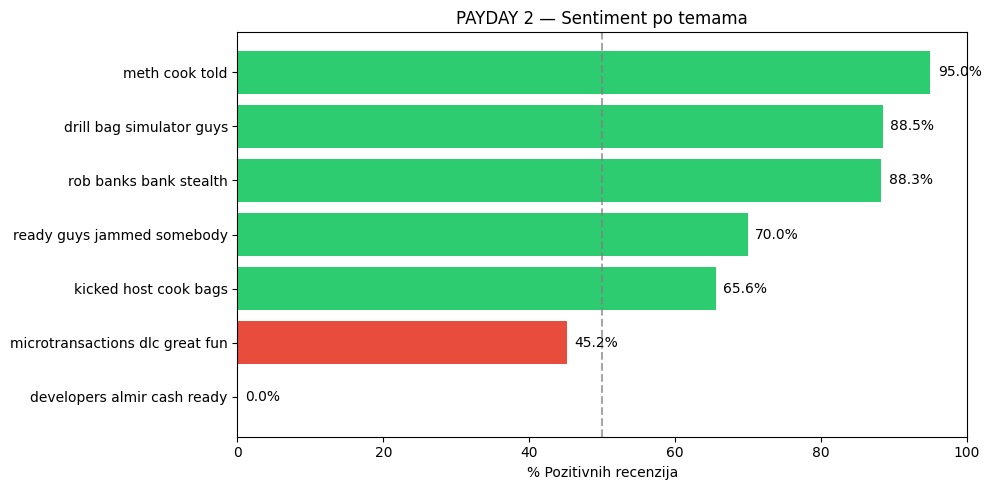

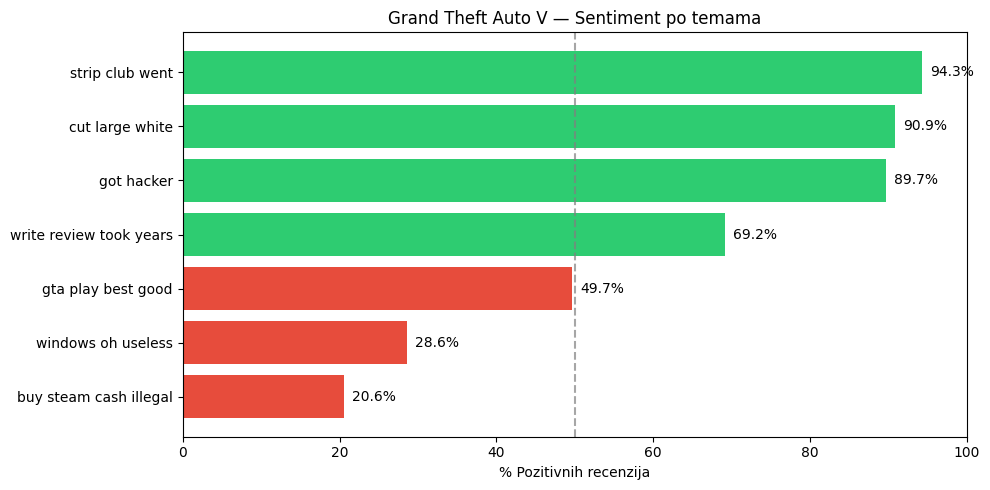

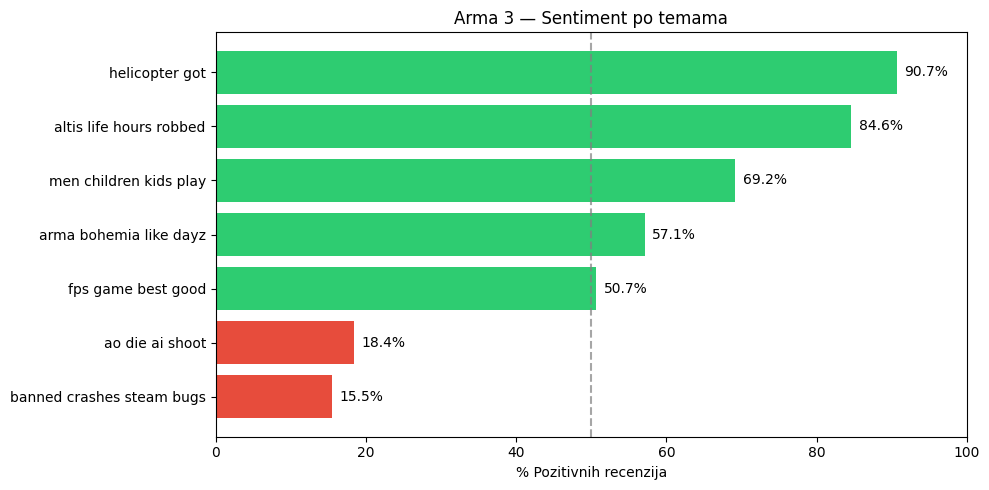

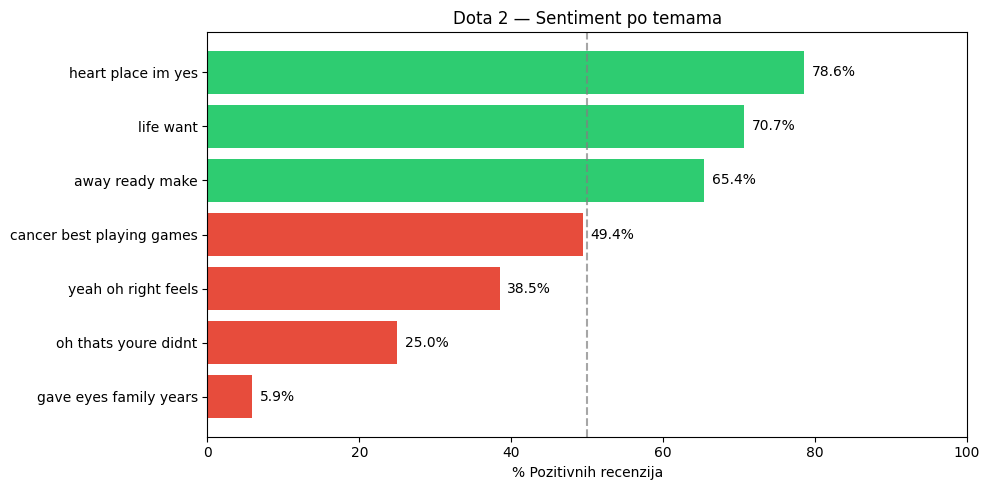

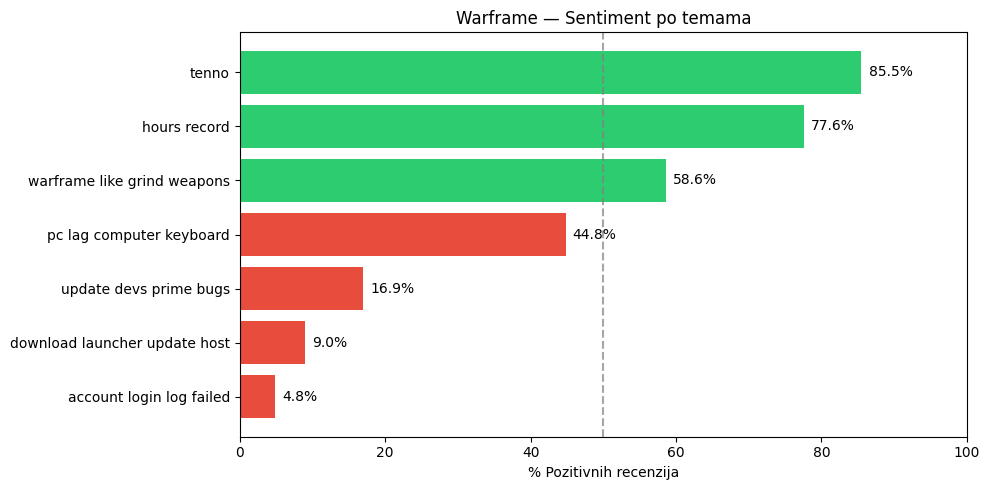

In [9]:
import matplotlib.pyplot as plt

df_topics = df[df['topic'] != -1].copy()

for game in games:
    game_df = df_topics[df_topics['app_name'] == game].copy()
    topic_info = game_models[game].get_topic_info()
    topic_info = topic_info[topic_info['Topic'] != -1][['Topic', 'Name']]
    game_df = game_df.merge(topic_info, left_on='topic', right_on='Topic')

    sentiment = game_df.groupby(['Name', 'review_score']).size().unstack(fill_value=0)
    sentiment.columns = ['negativne', 'pozitivne']
    sentiment['pct_pozitivnih'] = (sentiment['pozitivne'] / (sentiment['pozitivne'] + sentiment['negativne']) * 100).round(1)
    sentiment = sentiment.sort_values('pct_pozitivnih', ascending=True)

    sentiment.index = [clean_topic_name(name) for name in sentiment.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(sentiment.index, sentiment['pct_pozitivnih'], color=[
        '#e74c3c' if x < 50 else '#2ecc71' for x in sentiment['pct_pozitivnih']
    ])
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('% Pozitivnih recenzija')
    ax.set_title(f'{game} — Sentiment po temama')
    ax.set_xlim(0, 100)

    for bar, val in zip(bars, sentiment['pct_pozitivnih']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/ReviewDigest/{game}_sentiment_clean.png', dpi=150)
    plt.show()

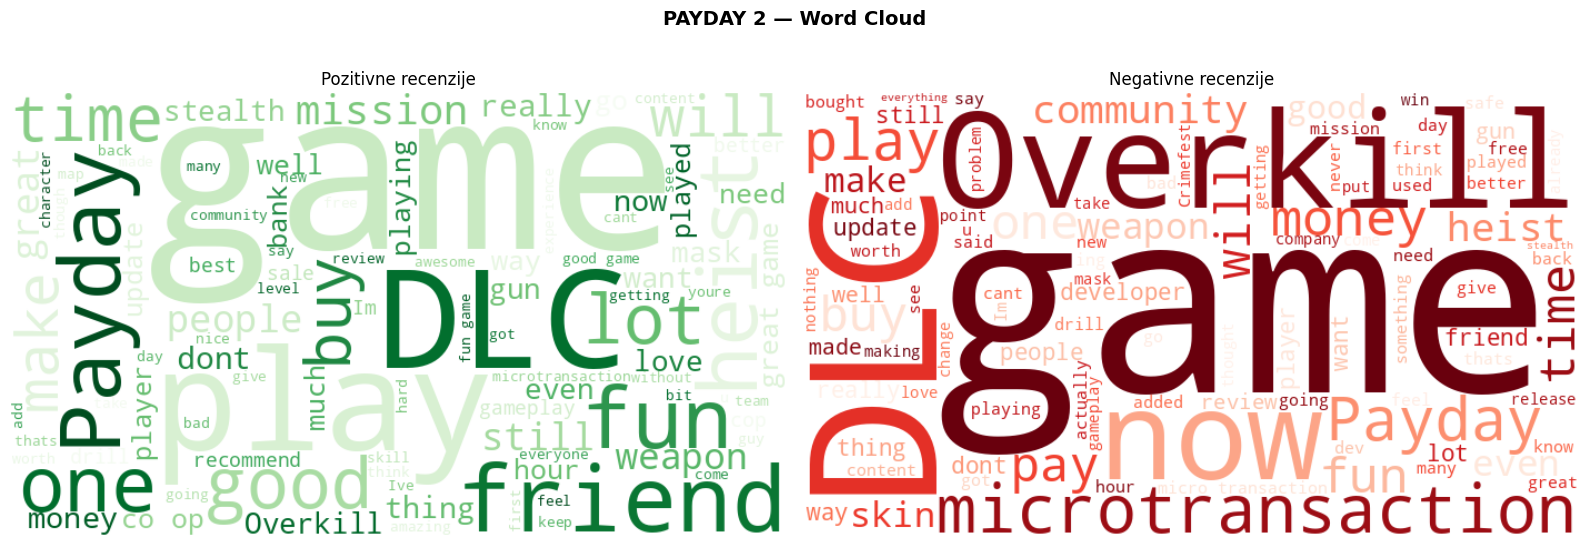

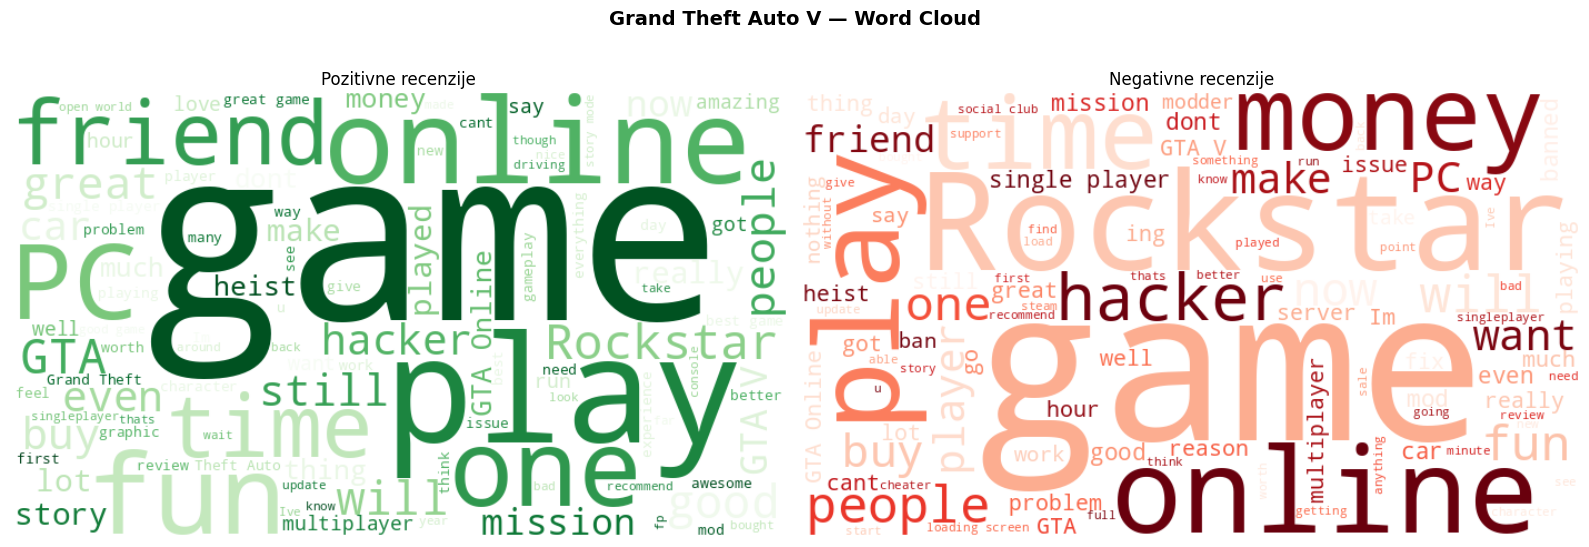

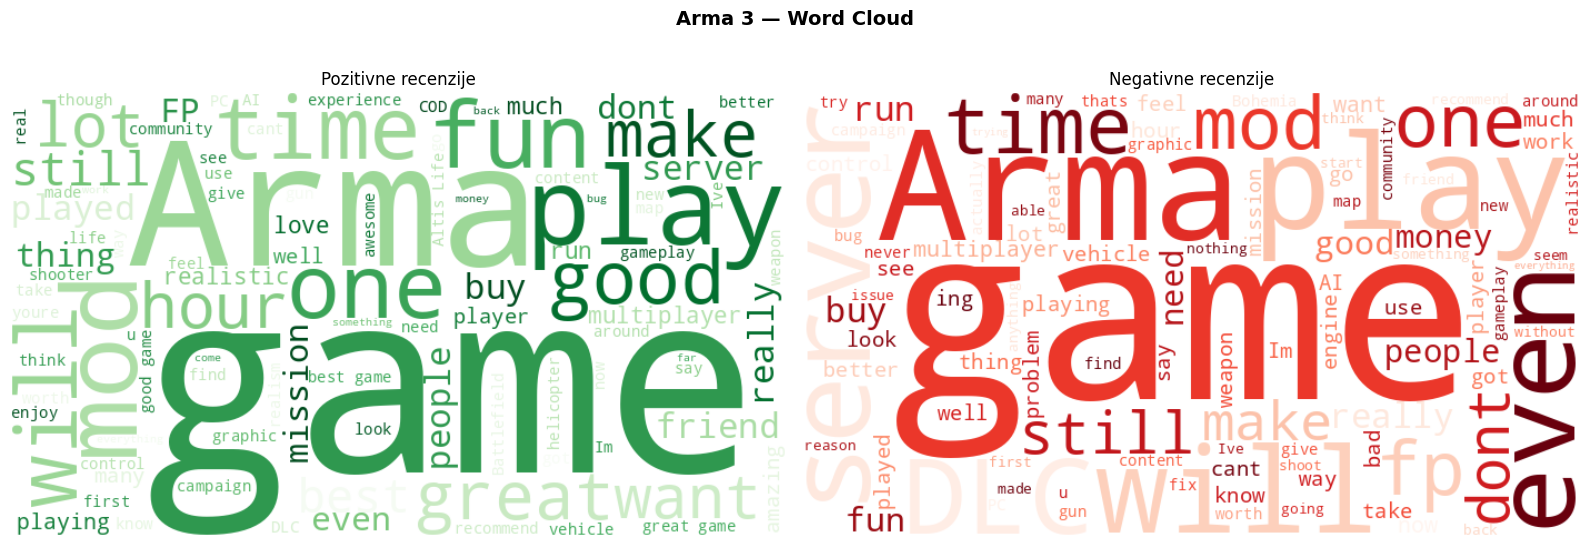

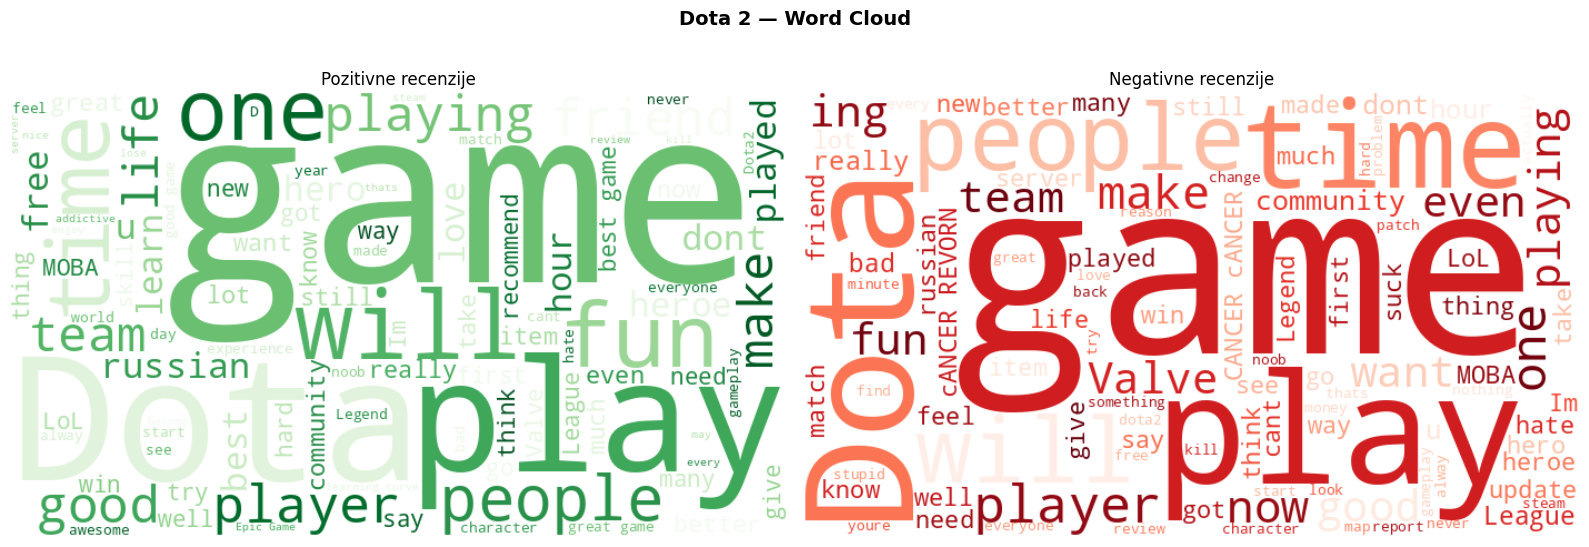

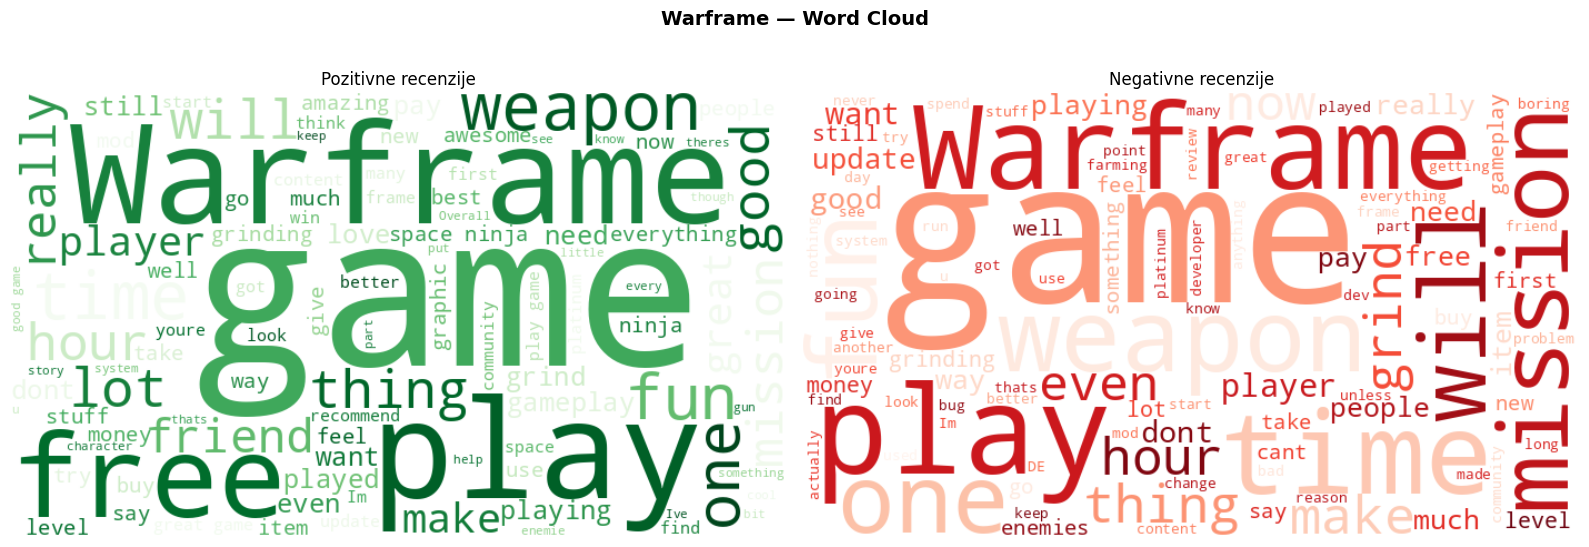

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for game in games:
    game_df = df[df['app_name'] == game]

    pos_text = ' '.join(game_df[game_df['review_score'] == 1]['review_text'])
    neg_text = ' '.join(game_df[game_df['review_score'] == -1]['review_text'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{game} — Word Cloud', fontsize=14, fontweight='bold')

    wc_pos = WordCloud(width=700, height=400, background_color='white',
                       colormap='Greens', stopwords=None,
                       max_words=100).generate(pos_text)

    wc_neg = WordCloud(width=700, height=400, background_color='white',
                       colormap='Reds', stopwords=None,
                       max_words=100).generate(neg_text)

    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('Pozitivne recenzije', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('Negativne recenzije', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/ReviewDigest/{game}_wordcloud.png', dpi=150)
    plt.show()